# COMSOL Full-Wave Simulation of a Coupled Quarter-Wave Resonator

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"
# or, from a checkout of this repository:
uv sync --extra comsol
# or with pip:
pip install "qpdk[comsol]"
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the full-wave solve needs a local COMSOL installation, a
license, and the RF Module. Google Colab has none of them, so the build cells
cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook takes a QPDK coupled quarter-wave resonator all the way to a
solved COMSOL model: it prepares the ported layout, builds the sheet model
with air and silicon domains, assigns PEC and numeric TEM ports, searches for
a mode near 11.6 GHz, sweeps a narrow window around the mode it selects, and
reads back real field and S-parameter results.

**What the saved output is.** It is a record of a COMSOL workflow and of the
diagnostic checks run against it, not a validated QPDK resonator frequency.
The 11.7102458 GHz dip it reports is an apparent feature of the current port
and enclosure setup: the mode behind it has not been shown to be localised on
the meander, its frequency has not been shown to be set by the physics rather
than by the mesh, and it disappears when the outer boundary changes. The
closing sections say what would have to be established first.

## How this page is published

The figures and numbers on this page are **saved cell outputs**. The numerical
data comes from licensed COMSOL solves; the plotting cells were rerun against
those exports and saved in the committed notebook. The documentation renders
that copy rather than running the cells again.

The whole path is scripted, so a licensed machine reproduces it end to end by
setting `RUN_COMSOL = True`. Without a license the notebook still runs from top
to bottom: the COMSOL cells are skipped, and every cell that reads results
prints how to supply them instead of plotting. On a fresh machine with neither
a license nor exported results you will therefore see the stored figures in the
documentation, but a local run prints skip messages rather than plots. To
replot locally, either export the files with `RUN_COMSOL = True`, or set
`RESULTS_DIR` to a directory that already holds an exported copy.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.quarter_wave_resonator_coupled`: a meandering
coplanar-waveguide (CPW) resonator placed alongside a straight feedline,
separated by a coupling gap. This is the standard hanger geometry used to read
out superconducting qubits {cite:p}`gopplCoplanarWaveguideResonators2008a`.

Two terminations define a **quarter-wave** resonator:

- The end nearest the feedline is **open**, where the voltage has an antinode.
- The far end is **shorted**, where the current has an antinode.

A line with one open and one shorted end resonates when its electrical length
is an odd multiple of $\lambda/4$. Close to resonance the coupling capacitor
loads the feedline and the transmission $|S_{21}|$ shows a **notch**: at the
resonant frequency, power that would travel from `coupling_o1` to
`coupling_o2` is largely reflected. The centre of the notch gives $f_r$ and
its width the loaded quality factor.

That is the textbook behaviour, and it is why the dip below was chased. It is
not a statement about this model. Whether the dip this notebook finds is such
a notch is a separate question, and the diagnostic sections below answer it in
the negative: no meander-localised mode has been demonstrated, and the mode
behind the dip does not survive a change of the outer boundary.

## The model behind the results

COMSOL's own RF example ["Coplanar Waveguide Resonator"](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
is the companion for this geometry. The model built here uses the same stack
and port approach:

1. A silicon block under the metal and an air region above, meeting at the
   metal plane.
2. **PEC on the metal sheets.** The metal is drawn as faces on the
   silicon/air interface rather than as a thin extruded solid, which meshes far
   more reliably for a metal that is three orders of magnitude thinner than the
   substrate.
3. **Numeric TEM ports** on two feed cross sections, each with a **voltage
   integration line** running from ground to the centre conductor. This is the
   usual transmission-line picture, in which the port mode is the quasi-TEM CPW
   mode and the S-parameters come from the travelling-wave amplitudes on the
   feedline {cite:p}`m.pozarMicrowaveEngineering2012`.
4. **Boundary mode analysis** study steps that solve the 2D cross-section
   eigenmode and supply each port's mode field.
5. An **eigenfrequency study** that searches six modes near an 11.6 GHz shift,
   followed by a **frequency-domain study** with COMSOL's adaptive frequency
   sweep enabled over a narrow window around the high-$Q$ mode the search
   selects. That mode is picked by frequency and loss ratio alone; its
   identity is not validated anywhere on this page.

Those five steps are what the cells below execute, in this order:

::::{only} html
```{mermaid}
flowchart TB
    A["Ported layout:<br>metal polygons and two open feed planes"]
    B["Sheet model:<br>air above, silicon below, metal faces at z = 0"]
    C["Physics:<br>PEC on the metal, and one numeric TEM port<br>per feed with a voltage integration line"]
    D["Mesh:<br>one automatic size setting"]
    E["Study:<br>one boundary mode analysis per port,<br>then an eigenfrequency search,<br>then an adaptive sweep around the mode found"]
    F["Results:<br>emw.S21dB, emw.S11dB, the mode spectrum,<br>and the emw.normE export at the dip"]
    A --> B --> C --> D --> E --> F
```
::::

::::{only} typst or typstpdf
The pipeline: ported layout, then the sheet model with air above and silicon
below, then PEC on the metal with one numeric TEM port per feed, then one
automatic mesh size, then a boundary mode analysis per port followed by an
eigenfrequency search and an adaptive sweep around the mode it finds, then the
S-parameter, mode, and field results.
::::

The outer air and silicon walls use COMSOL's default PEC boundary. This is a
finite conducting enclosure, whereas the reference includes scattering
boundaries, and the enclosure is a candidate explanation for the dip below:
swapping the four non-port outer walls for scattering boundaries makes the
11.71 GHz high-$Q$ eigenmode disappear. Which mechanism produces the dip is
not established, so the enclosure is a live suspect rather than a converged
boundary condition.

The same eigenfrequency search is re-run at a few mesh settings near the end
of this page, on this same enlarged layout. It follows one selected mode, and
neither that mode's identity nor its frequency is settled. That re-run is off
by default.

### What PEC leaves out

The QPDK metal is a superconductor, but this first model treats it as a
perfect electric conductor. PEC has zero surface resistance, so it predicts no
conductor loss, and it ignores the **kinetic inductance** of the film. It is a
useful first approximation for checking geometry, porting, and coupling, but a
measured quality factor cannot be predicted from it. The kinetic inductance
also shifts the resonance. Replacing PEC with a surface-impedance or transition boundary condition
is the next modelling step.

### The ported layout

`prepare_comsol_layout` inverts the M1 etch mask into a ground plane, and the
ground plane then *surrounds* the source feed ports, which sit at $x = 0$ and
$x = 200$ µm inside the prepared bounding box. A port face there would be
buried in ground metal, so those planes cannot be turned into TEM ports.

To expose them, this notebook extends each feed with a straight CPW section to
a plane clear of the whole resonator, then extracts with
`crop_to_feed_ports=True` so both external faces are open CPW cross sections.
**The extension is part of the modelled device**: it lengthens the feedline and
changes the coupling geometry, so whatever dip is solved here belongs to this
extended layout and not to the unextended reference cell.

### Locating the dip: eigenfrequency search, then an adaptive sweep

A hanger resonator can reach $Q \sim 10^4$ to $10^6$, so its fractional
linewidth can be $10^{-4}$ or smaller. A uniform sweep with 0.25 GHz spacing
samples the band but **cannot resolve a notch** that narrow: the feature falls
between two points and nothing in the exported curve shows it. Resolving a
feature that narrow therefore takes two steps, and this notebook does both.
What the two steps cannot do on their own is tell you whether the feature is
the resonator mode, which is the question the diagnostics below take up.

**First, an eigenfrequency study.** A model is built from the same layout with
the same air, silicon, and port setup, the frequency step is removed and an
`Eigenfrequency` step put in its place. It searches near a shift of 11.6 GHz
for six modes, and the modes come back as **complex** eigenfrequencies
$f = f' + i f''$: the real part is the mode frequency and the imaginary part
carries the damping. $f'/(2f'')$ would be an unloaded quality factor only if
that damping were the device's own, and here it is not: the PEC metal has no
conductor or dielectric loss, the two numeric feed ports are matched
terminations that load the line, and the mesh contributes error of its own. So
the loss ratio is used as a selection screen and nothing more. A mode whose
imaginary part is negligible next to its real part is taken as a high-$Q$
candidate, which is what a superconducting resonator is expected to look like
once its metal is treated as lossless PEC. The selection below takes the
lowest-frequency mode in 8 to 14 GHz with $|f''|/f' < 10^{-3}$, and writes the
whole spectrum next to the selected mode. Frequency and loss ratio are all the
selection looks at, so what it returns is a candidate mode with no claim
attached to its identity.

**Second, an adaptive sweep around that mode.** A second model is then built
from the same layout and solved over
`range(center - 0.1 MHz, 1 kHz, center + 0.1 MHz)`: a 200 kHz window at 1 kHz
spacing, which is 201 solutions, with COMSOL's **adaptive frequency sweep**
turned on and the reflection $|S_{11}|$ as its error indicator. The window is
deliberately narrow and placed on the mode the search selected, because a
coarse sweep over the whole band cannot resolve a notch this narrow.

What that produced is a **dip of $-15.298$ dB at 11.7102458 GHz**, at the
frequency of the selected eigenmode to within the 1 kHz spacing of the grid,
against $-0.0346$ and $-0.0110$ dB at the low and high edges of the window.
The reflection at the dip is $-0.158$ dB, so most of the incident power is
still reflected there. The mesh that produced it has 201 391 elements, and the
largest $|S_{11}|^2 + |S_{21}|^2$ over the sweep is 1.00011.

The sweep resolves a narrow dip rather than sampling a band, so the feature is
real in the sense that the solver put it there. **A dip at the eigenfrequency
the search itself selected is not evidence of a resonator resonance.** Two
checks argue against reading it as one:

- **No demonstrated meander-localised mode.** At the dip, the electric-field
  norm on the $z = 1$ µm plane has a 95th percentile inside the meander region
  of only **0.0666 times** the 95th percentile over the feed region. Nothing
  in the saved output shows energy piling up on the meander, which is what a
  resonator mode would have to do.
- **The selected frequency is not settled, and moves with the enclosure.**
  The same search returns 11.7102458 GHz at 201 391 elements, 11.7113091 GHz
  at 271 277, and 11.7137042 GHz at 458 644, a 3.46 MHz drift, far more than
  the whole 200 kHz window. Replacing the four non-port outer PEC walls with
  scattering boundaries makes the 11.71 GHz high-$Q$ eigenmode disappear, and
  port-free PEC and scattering diagnostic eigenstudies found no credible
  meander-localised mode either.

So the dip is an apparent feature of the current port and enclosure setup. It
may be an enclosure or termination artifact; its cause is not proven. No
quality factor is quoted from this curve, because the width it would come from
is set by a mesh that has not settled and a boundary that changes the answer.
An edge-mesh diagnostic aimed at the gap region is pending, so these readings
may be revised.

::::{admonition} Reading the numbers on this page
:class: warning

The values come from the licensed solves described below, but they are not a
validated device prediction, and the 11.7102458 GHz feature is not a
demonstrated resonator resonance. The metal is a perfect conductor with no
surface resistance or kinetic inductance, so conductor loss and its frequency
shift are missing. The feed extension
changes the layout relative to the reference cell. The selected mode drifts
3.46 MHz under mesh refinement, more than the width of the sweep window, and
it vanishes when the outer PEC walls become scattering boundaries, so the outer
boundary is not innocent either. No meander-localised mode has been
demonstrated. Treat the dip frequency and depth as unvalidated until the
checks in "Next steps" are done.
::::

**References:**
- [COMSOL "Coplanar Waveguide Resonator" model](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
- [COMSOL RF Module User's Guide](https://doc.comsol.com/6.3/doc/com.comsol.help.rf/RFModuleUsersGuide.pdf)
- [COMSOL Reference Manual: Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)
- MPh repository: https://github.com/MPh-py/MPh

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab, and the result cells will report that no exported "
        "results are present."
    )

In [2]:
import json
import re
from operator import itemgetter
from pathlib import Path
from typing import Any

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import axes as mpl_axes, font_manager
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.resonator import quarter_wave_resonator_coupled
from qpdk.config import PATH
from qpdk.simulation import (
    ComsolBoundingBox,
    add_cpw_rf_study,
    build_comsol_sheet_model,
    prepare_comsol_layout,
    refine_metal_plane_mesh,
)
from qpdk.tech import coplanar_waveguide

try:
    import mph
    from jpype import JInt
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None


def _outfit_titles() -> None:
    """Draw plot titles in Outfit bold, matching the documentation headings."""
    original_set_title = mpl_axes.Axes.set_title

    def _set_title(self: mpl_axes.Axes, *args: Any, **kwargs: Any) -> Any:
        kwargs.setdefault("fontfamily", "Outfit")
        kwargs.setdefault("fontweight", "bold")
        return original_set_title(self, *args, **kwargs)

    mpl_axes.Axes.set_title = _set_title


def apply_qpdk_style() -> str:
    """Apply the QPDK plot style, falling back to matplotlib's own defaults.

    The style is ``docs/qpdk.mplstyle`` in a checkout and the installed ``qpdk``
    style in a documentation environment; a downloaded notebook outside both
    keeps matplotlib's defaults instead of failing. The documentation fonts are
    used when they are installed, and matplotlib's bundled families otherwise.

    Returns:
        A short description of the style that was applied.
    """
    for source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
        try:
            plt.style.use(source)
        except OSError:
            continue
        applied = str(source)
        break
    else:
        applied = "matplotlib defaults"

    installed = {font.name for font in font_manager.fontManager.ttflist}
    plt.rcParams["font.sans-serif"] = [
        name
        for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
        if name in installed
    ] + ["sans-serif"]
    if "Outfit" in installed:
        _outfit_titles()
    return applied


def prefer_svg_figures() -> None:
    """Save every figure as SVG as well as PNG, so stored outputs stay vector.

    The saved cell outputs are what the documentation renders, and both the HTML
    and the Typst PDF build embed the SVG ahead of the PNG. The PNG is kept as a
    fallback for a viewer that cannot render SVG, and text is written as paths so
    the figures carry their own glyphs instead of relying on installed fonts.
    Outside a notebook kernel there is no inline backend to configure, so a
    plain script run keeps matplotlib's PNG default.
    """
    try:
        # Ships with ipykernel, so it is present in a notebook kernel only.
        from matplotlib_inline.backend_inline import (  # ruff: ignore[import-outside-top-level]
            set_matplotlib_formats,
        )
    except ImportError:
        return
    plt.rcParams["svg.fonttype"] = "path"
    set_matplotlib_formats("svg", "png")


def result_file(name: str) -> Path | None:
    """Return the path of an exported solver result, if one is available.

    Args:
        name: File name to look for inside ``RESULTS_DIR``.

    Returns:
        The path, or ``None`` when ``RESULTS_DIR`` is unset or holds no such file.
    """
    if RESULTS_DIR is None:
        return None
    path = RESULTS_DIR / name
    return path if path.exists() else None


def explain_missing_results(name: str) -> None:
    """Print how to supply a result file that is not on disk.

    Args:
        name: File name that was looked for inside ``RESULTS_DIR``.
    """
    print(
        f"No {name} in RESULTS_DIR ({RESULTS_DIR}). The figures on the "
        "documentation page are saved outputs of a licensed solve, and the cells "
        "here replot only from files on disk. To supply them, run with "
        "RUN_COMSOL = True on a licensed machine, which exports into MODEL_DIR, "
        "or set RESULTS_DIR to a directory that already holds an exported "
        f"{name}."
    )


def exported_frequency_ghz(file: Path) -> float | None:
    """Read the ``@ freq=`` annotation COMSOL writes into a data export header.

    Args:
        file: Exported text file to scan.

    Returns:
        The annotated frequency, in the model's frequency unit (GHz here), or
        ``None`` when the export carries no frequency.
    """
    with file.open(encoding="utf-8") as handle:
        for line in handle:
            if (match := re.search(r"@ freq=([0-9.eE+-]+)", line)) is not None:
                return float(match.group(1))
    return None


prefer_svg_figures()
STYLE_SOURCE = apply_qpdk_style()
print("Plot style: QPDK" if STYLE_SOURCE != "matplotlib defaults" else STYLE_SOURCE)

Plot style: QPDK


## Build the ported layout

The resonator is created with an explicit CPW cross-section so that the
centre-conductor width and the gap are known constants we reuse when
describing the ports. On the source cell the feed ports `coupling_o1` and
`coupling_o2` sit at $x = 0$ and $x = 200$ µm, well inside the prepared ground
plane. Each is extended to the left and right with a straight CPW of the same
cross-section, so the new feed planes at $x = -1320$ µm and $x = 2200$ µm are
clear of the resonator.

The ground reaches at least 1200 µm beyond the resonator in every lateral
direction. The prepared box spans $x=-1320\ldots2200$ µm and
$y=-2041\ldots1211$ µm. The larger box reduces the influence of the outer
PEC walls, but does not remove it: swapping those walls for scattering
boundaries later on removes the 11.71 GHz mode entirely, so the enclosure is
part of the setup that produces the dip rather than a settled boundary.

The feedline extensions put each port on an outer face while preserving an
open CPW cross section at the crop plane.

In [3]:
CPW_WIDTH_UM = 10.0
CPW_GAP_UM = 6.0
LEFT_EXTENSION_UM = 1320.0
RIGHT_EXTENSION_UM = 2000.0
GROUND_MARGIN_UM = 1200.0

cross_section = coplanar_waveguide(width=CPW_WIDTH_UM, gap=CPW_GAP_UM)

resonator = quarter_wave_resonator_coupled(
    length=4000.0,
    meanders=4,
    cross_section=cross_section,
    cross_section_non_resonator=cross_section,
    coupling_straight_length=200.0,
    coupling_gap=20.0,
)

component = gf.Component(name="comsol_cpw_resonator")
component << resonator

left_straight = component << gf.components.straight(
    length=LEFT_EXTENSION_UM, cross_section=cross_section
)
right_straight = component << gf.components.straight(
    length=RIGHT_EXTENSION_UM, cross_section=cross_section
)
left_straight.connect("o2", resonator.ports["coupling_o1"])
right_straight.connect("o1", resonator.ports["coupling_o2"])
component.add_port("input", port=left_straight.ports["o1"])
component.add_port("output", port=right_straight.ports["o2"])

print(f"Extended component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
for port in component.ports:
    print(
        f"  {port.name}: center={tuple(round(value, 3) for value in port.center)} µm, "
        f"width={port.width} µm, orientation={port.orientation}°"
    )

Extended component: comsol_cpw_resonator
Bounding box (µm): (-1320,-841;2200,11)
  input: center=(-1320.0, 0.0) µm, width=10.0 µm, orientation=180.0°
  output: center=(2200.0, 0.0) µm, width=10.0 µm, orientation=0.0°


In [4]:
layout = prepare_comsol_layout(
    component,
    feed_ports=("input", "output"),
    ground_margin=GROUND_MARGIN_UM,
    crop_to_feed_ports=True,
)

hole_count = sum(len(polygon.holes) for polygon in layout.polygons)
print(f"Metal polygons: {len(layout.polygons)} ({hole_count} holes total)")
print(f"Prepared bounding box (µm): {layout.bbox}")
for feed in layout.feed_ports:
    print(
        f"Feed {feed.name}: center={feed.center} µm, width={feed.width} µm, "
        f"orientation={feed.orientation}°"
    )

Metal polygons: 3 (1 holes total)
Prepared bounding box (µm): ComsolBoundingBox(xmin=-1320.0, ymin=-2041.0, xmax=2200.0, ymax=1211.0)
Feed input: center=(-1320.0, 0.0) µm, width=10.0 µm, orientation=180.0°
Feed output: center=(2200.0, 0.0) µm, width=10.0 µm, orientation=0.0°


The result is three metal polygons with one hole. One polygon is the ground
plane, and the hole is the CPW channel cut through it: the centre-conductor
strip, both etch gaps, and the surrounding ground all come from that one
outline-plus-hole shape. Cropping to the feed planes cut the ground back so
each external face shows an open CPW cross section instead of a wall of
ground, which is what lets the port solver define a mode there.

findfont: Failed to find font weight bold, now using 400.


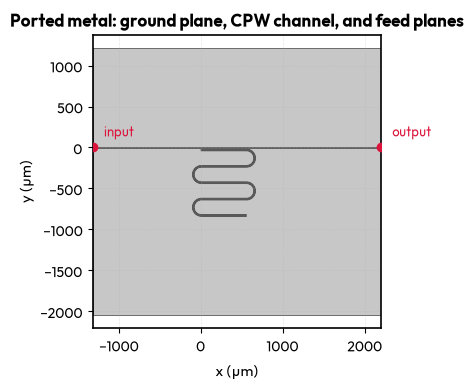

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for feed in layout.feed_ports:
    ax.plot(*feed.center, marker="o", color="crimson", markersize=6, zorder=4)
    ax.annotate(
        feed.name,
        feed.center,
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Ported metal: ground plane, CPW channel, and feed planes")
plt.tight_layout()
plt.show()

## Build the COMSOL model, physics, and study

Three calls turn the layout into a configured model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_rf.add_cpw_rf_study` selects the metal
  faces and applies PEC, adds two numeric TEM ports with voltage integration
  lines spanning the CPW gap, adds the mesh sequence, and adds a study with one
  boundary mode analysis step per port plus a frequency step. Every selection
  is derived from the layout geometry, so no face or edge ID is hard-coded.
- The last calls configure the study and run it.

The boundary mode steps use 11.6 GHz as their reference and search near an
effective mode index of 2.5, following the COMSOL CPW reference. The port
mode is then used by both the eigenfrequency search and the sweep. Check
passivity before using a sweep for design decisions: a passive two-port should
have $|S_{11}|^2 + |S_{21}|^2 \leq 1$ within numerical tolerance.

The licensed branch below runs **two** models in sequence from the same
layout, at automatic mesh size 2:

1. An eigenfrequency model, solved for six modes near 11.6 GHz. Its spectrum
   is read off, the lowest-frequency high-$Q$ candidate in 8 to 14 GHz is
   selected, and the model is removed from the client once its data is
   recorded. `neigs` is set with a Java int (`JInt`): a plain Python int is
   ambiguous across COMSOL's overloaded setters and JPype cannot pick one.
2. The sweep model, whose frequency step is centred on the selected mode with
   the adaptive sweep enabled.

The first model's data is recorded before it is removed, so a sweep that fails
still leaves the eigenfrequency spectrum on disk.

`mph.start(cores=...)` launches a local COMSOL process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The whole block is off by default so the notebook
runs without one; set `RUN_COMSOL = True` on a licensed machine to build, solve,
and save the model.

`RUN_EIGEN_MESH_STUDY` turns on the mesh-refinement series further down this
page. That series builds a fresh model and re-runs the same eigenfrequency
search, following the same selected mode, once per row of
`EIGEN_CONVERGENCE_CONFIGS`, so it needs
`RUN_COMSOL = True` for the client and it costs a full build, mesh, and solve
per row. It rewrites its JSON after every row, so interrupting a long series
keeps the rows already solved. It is off by default.

`RESULTS_DIR` is where the cells that read results look for exported files. It
defaults to `None` so that a run without a license skips those cells, and to
`MODEL_DIR` when `RUN_COMSOL` is `True`, because the licensed branch below
exports into `MODEL_DIR`. Point it at any directory of exported files to replot
an existing run without starting COMSOL, for example
`RESULTS_DIR = Path("exports")`.

In [6]:
RUN_COMSOL = False
# Eigenfrequency convergence series below. Slow, and needs RUN_COMSOL.
RUN_EIGEN_MESH_STUDY = False
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_cpw_resonator.mph"
RESULTS_DIR: Path | None = MODEL_DIR if RUN_COMSOL else None
CORES = 4
# Eigenfrequency search and the adaptive sweep around the mode it selects.
EIGEN_REFERENCE_GHZ = 11.6
EIGEN_MODE_COUNT = 6
EIGEN_BAND_GHZ = (8.0, 14.0)
# A mode whose imaginary part is under this fraction of its real part counts as
# high-Q. A lossless-PEC resonator mode clears it; a damped one does not.
EIGEN_LOSS_RATIO = 1e-3
SWEEP_MESH_SIZE = 2
# 200 kHz window at 1 kHz spacing around the selected mode, which is 201 points.
SWEEP_HALF_WIDTH_GHZ = 0.0001
SWEEP_STEP_GHZ = 0.000001
SWEEP_CSV = "comsol_cpw_sparameters.csv"
EIGEN_JSON = "comsol_cpw_eigenfrequencies.json"


def mesh_element_count(model: Any) -> int:
    """Return the number of 3D mesh elements in a model's mesh.

    Args:
        model: A built and meshed MPh model.

    Returns:
        The number of mesh elements.
    """
    return int(model.java.component("comp1").mesh("mesh1").getNumElem())


def configure_eigenfrequency_study(model: Any) -> None:
    """Swap a CPW study's frequency step for an eigenfrequency search.

    Shift and mode count come from ``EIGEN_REFERENCE_GHZ`` and
    ``EIGEN_MODE_COUNT``, so the primary solve and the convergence series below
    search the same part of the spectrum the same way.

    Args:
        model: A model that
            :func:`~qpdk.simulation.comsol_rf.add_cpw_rf_study` has already
            given a frequency study to.
    """
    study = model.java.study("std1")
    study.feature().remove("freq")
    study.create("eig", "Eigenfrequency")
    eigen_feature = study.feature("eig")
    eigen_feature.set("shiftactive", "on")
    eigen_feature.set("shift", f"{EIGEN_REFERENCE_GHZ}[GHz]")
    eigen_feature.set("neigsactive", "on")
    # neigs needs a Java int: JPype cannot pick between COMSOL's overloaded
    # setters for a plain Python int.
    eigen_feature.set("neigs", JInt(EIGEN_MODE_COUNT))


def select_high_q_mode(modes: list[complex]) -> complex:
    """Return the lowest-frequency high-Q mode inside the search band.

    Args:
        modes: Complex eigenfrequencies in Hz, real part the mode frequency and
            imaginary part its damping.

    Returns:
        The selected mode.

    Raises:
        ValueError: If no mode inside ``EIGEN_BAND_GHZ`` has an imaginary part
            under ``EIGEN_LOSS_RATIO`` of its real part.
    """
    high_q_modes = [
        mode
        for mode in modes
        if EIGEN_BAND_GHZ[0] * 1e9 < mode.real < EIGEN_BAND_GHZ[1] * 1e9
        and abs(mode.imag) / mode.real < EIGEN_LOSS_RATIO
    ]
    if not high_q_modes:
        raise ValueError(
            "The eigenfrequency search found no high-Q mode between "
            f"{EIGEN_BAND_GHZ[0]:g} and {EIGEN_BAND_GHZ[1]:g} GHz: {modes}"
        )
    return min(high_q_modes, key=lambda mode: mode.real)


model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)

    eigen_model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Coupled Quarter-Wave Resonator eigenmodes",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_cpw_rf_study(
            eigen_model,
            layout,
            cpw_gap_um=CPW_GAP_UM,
            frequency_ghz=EIGEN_REFERENCE_GHZ,
            mesh_size=SWEEP_MESH_SIZE,
        )
        configure_eigenfrequency_study(eigen_model)
        eigen_model.java.component("comp1").mesh("mesh1").run()
        eigen_element_count = mesh_element_count(eigen_model)
        eigen_model.java.study("std1").run()
        for problem in eigen_model.problems():
            print(f"  eigenfrequency model reports: {problem}")
        # Eigenfrequencies come back complex: f' is the mode frequency and f''
        # its damping. Not the device Q: PEC has no loss and the ports are
        # matched loads, so the damping is port loading plus mesh error.
        eigen_modes = [
            complex(value)
            for value in np.atleast_1d(eigen_model.evaluate("freq")).ravel()
        ]
    finally:
        client.remove(eigen_model)

    print(f"Eigenfrequency solve: {eigen_element_count} elements")
    for index, mode in enumerate(eigen_modes, start=1):
        print(
            f"  mode {index}: {mode.real / 1e9:.6f} GHz "
            f"{mode.imag / 1e6:+.4f} MHz imaginary"
        )

    selected_mode = select_high_q_mode(eigen_modes)
    center_ghz = selected_mode.real / 1e9
    print(f"Selected mode: {center_ghz:.9f} GHz")

    eigen_path = MODEL_DIR / EIGEN_JSON
    eigen_path.write_text(
        json.dumps(
            {
                "mesh_size": SWEEP_MESH_SIZE,
                "element_count": eigen_element_count,
                "shift_ghz": EIGEN_REFERENCE_GHZ,
                "modes_hz": [
                    {"real": mode.real, "imag": mode.imag} for mode in eigen_modes
                ],
                "selected_mode_hz": {
                    "real": selected_mode.real,
                    "imag": selected_mode.imag,
                },
                "selection": {
                    "band_ghz": list(EIGEN_BAND_GHZ),
                    "max_loss_ratio": EIGEN_LOSS_RATIO,
                },
            },
            indent=2,
        )
        + "\n"
    )
    print(f"Saved eigenfrequencies to {eigen_path}")

    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Coupled Quarter-Wave Resonator",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    add_cpw_rf_study(
        model,
        layout,
        cpw_gap_um=CPW_GAP_UM,
        frequency_ghz=EIGEN_REFERENCE_GHZ,
        mesh_size=SWEEP_MESH_SIZE,
    )
    sweep_feature = model.java.study("std1").feature("freq")
    sweep_feature.set(
        "plist",
        f"range({center_ghz - SWEEP_HALF_WIDTH_GHZ:.9f}[GHz],"
        f"{SWEEP_STEP_GHZ}[GHz],{center_ghz + SWEEP_HALF_WIDTH_GHZ:.9f}[GHz])",
    )
    sweep_feature.set("awe", "on")
    sweep_feature.set("awefunc", ["abs(comp1.emw.S11)"])
    model.java.component("comp1").mesh("mesh1").run()
    model.java.study("std1").run()
    model.save(MODEL_PATH)

    solved_frequencies_ghz = np.atleast_1d(model.evaluate("freq")).ravel().real / 1e9
    solved_s21_db = np.atleast_1d(model.evaluate("emw.S21dB")).ravel().real
    solved_s11_db = np.atleast_1d(model.evaluate("emw.S11dB")).ravel().real
    solved_power_sum = 10 ** (solved_s21_db / 10) + 10 ** (solved_s11_db / 10)
    if solved_power_sum.max() > 1.001:
        raise ValueError("The solved sweep violates passive two-port power balance")
    print(f"Solved {solved_frequencies_ghz.size} frequency points")
    print(f"Saved model to {MODEL_PATH}")

    sweep_path = MODEL_DIR / SWEEP_CSV
    np.savetxt(
        sweep_path,
        np.column_stack([solved_frequencies_ghz, solved_s21_db, solved_s11_db]),
        delimiter=",",
        header="frequency_ghz,s21_db,s11_db",
        comments="",
    )
    print(f"Saved sweep to {sweep_path}")

    notch_index = int(np.argmin(solved_s21_db))
    print(
        f"At {solved_frequencies_ghz[notch_index]:.9f} GHz, the sweep minimum: "
        f"S21 = {solved_s21_db[notch_index]:+.3f} dB, "
        f"S11 = {solved_s11_db[notch_index]:+.3f} dB"
    )
    print(
        f"At the window edges: "
        f"S21 = {solved_s21_db[0]:+.3f} and {solved_s21_db[-1]:+.3f} dB"
    )

The dip sits on the selected eigenfrequency and the window edges are more than
15 dB above it. That locates the feature and says nothing more: a dip at the
frequency of a mode the search itself chose is a consistency check between two
solves, not a resonance measurement. The depth is set by the coupling and by
whatever damping the model carries. The metal is PEC, so there is no conductor
or dielectric loss, but the two numeric feed ports are matched terminations, so
a lossless model can still show a real external decay; numerical error sits on
top of that. Whatever the split, the depth is not a prediction of a fabricated
device. Converting the dip into a loaded quality factor would need a converged
width, and neither the mesh nor the outer boundary is converged: refining moves
the mode by more than this whole window, and removing the outer PEC walls
removes the mode.

### Exporting a field map

The electric-field map shown further down this page was written from the
solved sweep model with COMSOL's Data export on a cut plane at $z = 1$ µm,
exported at the solution where $|S_{21}|$ is smallest, that is at the dip.
The same export is scripted below: a `CutPlane` dataset over the $xy$ plane,
then a `Data` result export with the expression `emw.normE`. It runs inside
the licensed branch, next to the solve, and writes into `MODEL_DIR`, where
`RESULTS_DIR` picks it up.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["emw.normE"])
    field_export.set("innerinput", "manual")
    field_export.set("solnum", str(notch_index + 1))
    field_export.set("filename", str(MODEL_DIR / "comsol_cpw_field.txt"))
    field_export.run()
    print(
        f"Exported emw.normE at {solved_frequencies_ghz[notch_index]:.9f} GHz to "
        f"{MODEL_DIR / 'comsol_cpw_field.txt'}"
    )

## Transmission sweep

This cell replots the exported sweep `frequency_ghz, s21_db, s11_db` and reads
its minimum out of the file, so the dip frequency and depth printed here come
from the data rather than from any assumed value. The sweep is 200 kHz wide at
1 kHz spacing, centred on the eigenfrequency selected above, which is why the x
axis below is an offset in kHz: 0 kHz is the deepest point of the exported
curve.

What the curve shows is a **narrow dip**, a little over 15 dB deep, with
transmission close to flat at the edges of the window. The two edges do not sit
at the same level, so the response is not symmetric about the window, but the
minimum still falls at its centre to within the spacing of the grid. Three
caveats belong with it. A dip only counts as a resonance if the mode behind it
is the resonator mode, and that has not been shown here. The depth is set by
the coupling and by whatever damping the model carries: the PEC metal adds no
conductor or dielectric loss, but the matched numeric feed ports give a
physical external decay on their own, with numerical error on top, so the depth
is not a fabricated-device prediction and cannot be read as one kind of loss.
And the width, which is what a quality factor would come from, is not
trustworthy while the mesh is still moving the selected mode by more than the
window width and the outer PEC walls are still able to remove the mode, so no
$Q$ is quoted from this curve.

With `RESULTS_DIR` unset, or set to a directory without the export, the cell
prints how to supply the file and draws nothing.

Sweep points: 201, 11.710146 to 11.710346 GHz
Dip: S21 = -15.298 dB at 11.710246 GHz, S11 = -0.158 dB there
At the window edges: S21 = -0.035 and -0.011 dB, S11 = -21.074 and -25.800 dB
Largest |S11|² + |S21|² = 1.000109


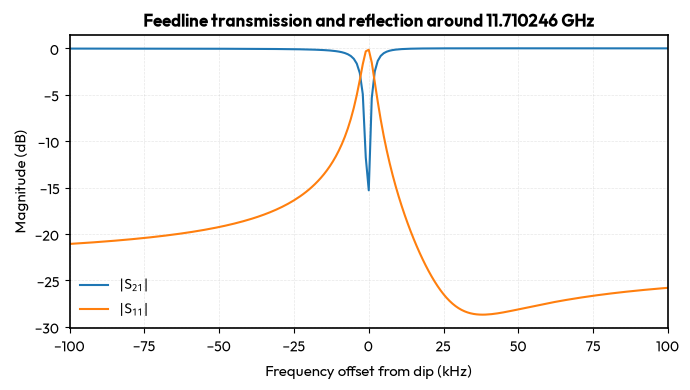

In [8]:
sweep_file = result_file(SWEEP_CSV)

if sweep_file is None:
    explain_missing_results(SWEEP_CSV)
else:
    SPARAMETERS = np.atleast_1d(np.genfromtxt(sweep_file, delimiter=",", names=True))
    sweep_ghz = SPARAMETERS["frequency_ghz"]
    sweep_s21_db = SPARAMETERS["s21_db"]
    sweep_s11_db = SPARAMETERS["s11_db"]
    power_sum = 10 ** (sweep_s21_db / 10) + 10 ** (sweep_s11_db / 10)
    if power_sum.max() > 1.001:
        raise ValueError("The saved sweep violates passive two-port power balance")

    notch = int(np.argmin(sweep_s21_db))
    notch_ghz = float(sweep_ghz[notch])
    offset_khz = (sweep_ghz - notch_ghz) * 1e6
    print(
        f"Sweep points: {sweep_ghz.size}, "
        f"{sweep_ghz.min():.6f} to {sweep_ghz.max():.6f} GHz"
    )
    print(
        f"Dip: S21 = {sweep_s21_db[notch]:+.3f} dB at {notch_ghz:.6f} GHz, "
        f"S11 = {sweep_s11_db[notch]:+.3f} dB there"
    )
    print(
        "At the window edges: "
        f"S21 = {sweep_s21_db[0]:+.3f} and {sweep_s21_db[-1]:+.3f} dB, "
        f"S11 = {sweep_s11_db[0]:+.3f} and {sweep_s11_db[-1]:+.3f} dB"
    )
    print(f"Largest |S11|² + |S21|² = {power_sum.max():.6f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(offset_khz, sweep_s21_db, label=r"$|S_{21}|$")
    ax.plot(offset_khz, sweep_s11_db, label=r"$|S_{11}|$")
    ax.set_xlabel("Frequency offset from dip (kHz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"Feedline transmission and reflection around {notch_ghz:.6f} GHz")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

The dip is where the eigenfrequency search said the selected mode would be: the
search found a high-$Q$ candidate, the sweep was centred on it, and the minimum
of the exported curve falls at that centre to within the 1 kHz spacing of the
grid. The two are independent solves on separately built models, so their
agreement checks the study setup and locates the feature. It is not a
convergence check and it does not identify the mode: both models share the same
mesh size and the same finite PEC enclosure, mesh refinement moves the selected
mode by more than the width of the window, and the mode is gone when those
walls become scattering boundaries.

## Field map

The exported field is the electric-field norm on the $z = 1$ µm plane at the
exported frequency, read from the export's own `@ freq=` annotation rather than
assumed. It is the solution at the dip. The metal sheet lies at $z = 0$ and
the plane sits just above it, so the map shows the field in the CPW gaps of
whatever metal the plane cuts through. This map uses automatic mesh size 2, the
setting the primary eigenfrequency search above solved on.

The export covers the whole prepared box, and outside the device the field
falls to values far below the ones near the metal, so plotting all of it on a
colour scale wide enough to hold the whole range washes the device out. The
figure below therefore crops the nodes to a window around the coupling section,
the meander, and the feedline, and takes its colour limits from percentiles of
the cropped data rather than from the full-domain maximum. Cropping happens
before the triangulation, so the saved SVG carries only the nodes inside the
window.

Field nodes: 6758 of 22848 inside the view; range 1.12e+07 to 5.56e+08 V/m, 1st to 99th percentile 1.29e+07 to 5.23e+08 V/m


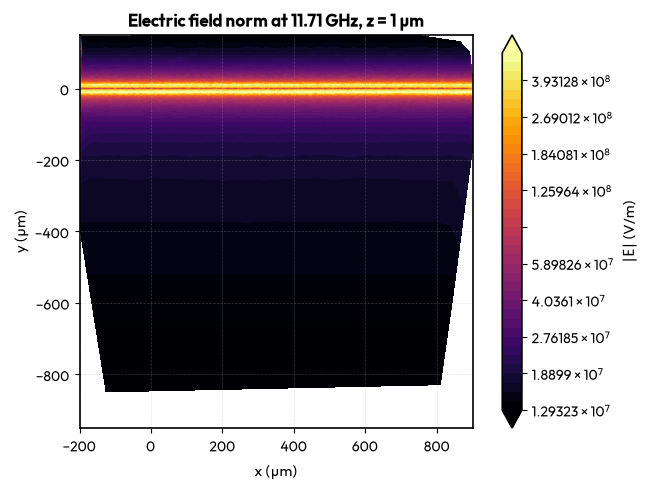

In [9]:
FIELD_TXT = "comsol_cpw_field.txt"
# xmin, xmax, ymin, ymax: the coupling section, the meander, and the feedline.
FIELD_VIEW_UM = (-200.0, 900.0, -950.0, 150.0)
field_file = result_file(FIELD_TXT)

if field_file is None:
    explain_missing_results(FIELD_TXT)
else:
    field = np.loadtxt(field_file, comments="%")
    field_x, field_y, field_e = field[:, 0], field[:, 1], field[:, 3]

    # Crop before triangulating: only the nodes in the window reach the figure,
    # and with them the SVG the documentation embeds.
    field_view = (
        (field_x >= FIELD_VIEW_UM[0])
        & (field_x <= FIELD_VIEW_UM[1])
        & (field_y >= FIELD_VIEW_UM[2])
        & (field_y <= FIELD_VIEW_UM[3])
    )
    view_x, view_y, view_e = (
        field_x[field_view],
        field_y[field_view],
        field_e[field_view],
    )
    if view_e.size == 0:
        raise ValueError(f"No exported field nodes inside {FIELD_VIEW_UM}")

    # Colour limits from the data in the window rather than the full-domain
    # maximum, which sits far outside it and flattens everything on the scale.
    color_min, color_max = (float(value) for value in np.percentile(view_e, [1, 99]))
    print(
        f"Field nodes: {view_e.size} of {field_e.size} inside the view; "
        f"range {view_e.min():.3g} to {view_e.max():.3g} V/m, "
        f"1st to 99th percentile {color_min:.3g} to {color_max:.3g} V/m"
    )

    field_frequency_ghz = exported_frequency_ghz(field_file)
    frequency_label = (
        f"{field_frequency_ghz:g} GHz, " if field_frequency_ghz is not None else ""
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    contour = ax.tricontourf(
        view_x,
        view_y,
        view_e,
        levels=np.geomspace(color_min, color_max, 40),
        norm=LogNorm(vmin=color_min, vmax=color_max),
        cmap="inferno",
        extend="both",
    )
    ax.set_xlim(FIELD_VIEW_UM[0], FIELD_VIEW_UM[1])
    ax.set_ylim(FIELD_VIEW_UM[2], FIELD_VIEW_UM[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Electric field norm at {frequency_label}z = 1 µm")
    fig.colorbar(contour, ax=ax, label=r"$|\mathbf{E}|$ (V/m)")
    plt.tight_layout()
    plt.show()

In this plane the field is largest along the feedline and the coupling section,
where it reaches a few times $10^8$ V/m in the gaps either side of the centre
conductor, and the strongest region follows the metal rather than filling the
substrate. Taking the 95th percentile inside a meander region and the same
percentile over the feed region gives a ratio of **0.0666**: at the dip, the
meander field is roughly fifteen times weaker than the feed field. The
ordering is the opposite of what a meander-localised mode would produce.

What this map does **not** show:

- **A meander-localised mode.** The field over the meander is weak, and a
  single cut plane at one frequency could not establish localisation anyway.
  That check needs the same field compared against a cut at a frequency off the
  dip, or against a mode whose eigenfrequency and field both identify it as the
  resonator mode. Neither has been done here.
- **A driven-meander field.** The feedline is driven directly, so a strong
  feedline field is expected at any frequency in the window and is not by
  itself a resonance signature.

What the map does support is narrower: the exported solution has its field
concentrated in the CPW gaps of this geometry, which is where an
under-resolved mesh would smear it. That says the export is sane, not that the
dip is a resonance.

## Mesh-refinement series on the selected mode

Re-solving one model with everything but the element size held fixed, and
watching how a quantity moves as the mesh is refined, is the usual test for
whether a discretised number is set by the physics. COMSOL's guidance on
running and reading that test is in
[Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html).

**This series is not a convergence study of the resonator frequency.** Every
row re-runs the eigenfrequency search of the main branch above, on the current
enlarged layout, with the same PEC metal, the same two numeric TEM ports, the
same 11.6 GHz shift, the same six requested modes, and the same high-$Q$
selection in 8 to 14 GHz. What it follows is one *selected* mode, chosen by
frequency and loss ratio alone, and nothing here shows that mode is the
resonator mode. So the series measures how a selected eigenvalue moves under
refinement, which is a statement about the search and the mesh, not about a
physical resonance. Each row builds a fresh model and records the mesh element
count, the frequency of the selected mode, and that mode's imaginary part.

Two mesh controls appear, because they are the two ways to spend elements:

- the **automatic mesh size**, COMSOL's overall physics-controlled size, here
  at sizes 2 and 1 (finer);
- **localized refinement** of the metal plane on top of automatic size 2, from
  a `Refine` feature restricted to a box around the metal plane, where the
  field concentrates.

They are separate controls rather than two dials on one thing, so the
automatic-size rows and the refined rows are different statements about the
model and the elements each one adds are not interchangeable. That is why the
plot below labels every point with the setting that produced it, and why the
two controls are drawn as separate series.

On this enlarged layout, with the dip of the main branch at 11.710 GHz, the
three rows that completed are:

- automatic size 2: 201 391 elements, selected mode at 11.7102458 GHz,
  imaginary part 1694.030 Hz.
- automatic size 1: 271 277 elements, selected mode at 11.7113091 GHz,
  imaginary part 147.606 Hz.
- size 2 with 2 localized passes: 458 644 elements, selected mode at
  11.7137042 GHz, imaginary part 930.375 Hz.

**The selected frequency has not converged.** Refining the mesh moves it by
3.46 MHz across these three rows, more than seventeen times the width of the
200 kHz sweep window the dip sits in above, and the movement does not shrink as
elements are added: the largest step is the last one. The imaginary part does
not settle either: it goes 1694.030 Hz, then 147.606 Hz, then 930.375 Hz, so it
moves non-monotonically with the mesh and is not converged. This model has no
conductor or dielectric loss, so the imaginary part mixes numerical error with
the external decay the matched feed ports impose, and no quality factor read
from it can be attributed to either. The size 2 row reproduces the primary
eigenfrequency solve of the main branch to the digits printed there, which is a
check that the series is measuring the same mode, not that the mode is physical.

A fourth row was attempted, size 2 with 3 localized passes over a broad mesh.
It was canceled after roughly 1.08 million elements because memory kept
growing, so it produced no result and is **not** part of this series; the
settings are no longer listed in `EIGEN_CONVERGENCE_CONFIGS`. Re-running it
needs a memory plan first, and refining further is a weak move while the
identity of the mode is still open.

The enclosure is the more pressing matter, and it is not a mesh question: no
amount of refinement removes it. Swapping the four non-port outer PEC walls for
scattering boundaries makes the 11.71 GHz high-$Q$ eigenmode disappear, and
port-free PEC and scattering diagnostic eigenstudies found no credible
meander-localised mode. A mode that only exists inside a particular enclosure
and only shows up as a weak meander field is not yet a resonator mode.

The series is off by default. Set `RUN_EIGEN_MESH_STUDY = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. It is the most
expensive block on this page: one fresh build, mesh, and eigenfrequency solve
per row. A row that fails to mesh or solve is printed in full and left out of
the table, and the settings that failed are kept in the JSON next to the rows
that were written.

In [10]:
EIGEN_CONVERGENCE_JSON = "comsol_cpw_eigen_convergence.json"
EIGEN_LOCAL_BASE_MESH_SIZE = 2
EIGEN_REFINE_Z_HALF_UM = 20.0
# The prepared ground box is 3.5 by 3.25 mm; refining all of it would spend
# elements on empty ground, so restrict the refine box to the resonator and its
# coupling section.
REFINE_BOX = ComsolBoundingBox(xmin=-200.0, ymin=-1000.0, xmax=800.0, ymax=120.0)
# (automatic mesh size, localized refine passes) per row. A 3-pass row was tried
# and canceled around 1.08M elements as memory grew, so it is not listed.
EIGEN_CONVERGENCE_CONFIGS = (
    (2, 0),
    (1, 0),
    (EIGEN_LOCAL_BASE_MESH_SIZE, 2),
)


def write_json_atomically(path: Path, payload: dict[str, Any]) -> None:
    """Write JSON through a sibling temporary file, then replace in place.

    The series writes on every row, so an interrupt partway through still leaves
    the rows already solved on disk. The temporary file is a sibling so the
    replace stays a same-filesystem rename, which is what makes it atomic.

    Args:
        path: The JSON file to write.
        payload: The object to serialise.
    """
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2) + "\n")
    temporary.replace(path)


def convergence_label(mesh_size: int, refine_passes: int) -> str:
    """Name one convergence row after the mesh controls that produced it.

    Args:
        mesh_size: COMSOL automatic mesh size.
        refine_passes: Localized refine passes applied on top of it.

    Returns:
        A label naming both controls.
    """
    if refine_passes == 0:
        return f"size {mesh_size}"
    return f"size {mesh_size} + {refine_passes} local passes"


def solve_cpw_eigen_row(
    client: Any, mesh_size: int, refine_passes: int
) -> dict[str, Any]:
    """Build, mesh, and solve one eigenfrequency convergence row.

    A fresh model is built per row so nothing carries over from another setting,
    and it is removed from the client even when the mesh or the solve raises.
    The physics and the eigenfrequency search match the main branch above, so
    every row measures the same mode.

    Args:
        client: The MPh client the licensed branch already started.
        mesh_size: COMSOL automatic mesh size, 1 (finest) to 9 (coarsest).
        refine_passes: Refine passes applied to ``REFINE_BOX`` on top of the
            automatic size. ``0`` meshes at the automatic size alone.

    Returns:
        A row holding the label, both mesh controls, the element count, the
        selected mode, and the full mode spectrum.

    Raises:
        RuntimeError: If the mesh produced no elements.
    """
    label = convergence_label(mesh_size, refine_passes)
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK CPW eigen convergence, {label}",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_cpw_rf_study(
            temp_model,
            layout,
            cpw_gap_um=CPW_GAP_UM,
            frequency_ghz=EIGEN_REFERENCE_GHZ,
            mesh_size=mesh_size,
        )
        configure_eigenfrequency_study(temp_model)
        if refine_passes == 0:
            temp_model.java.component("comp1").mesh("mesh1").run()
            element_count = mesh_element_count(temp_model)
        else:
            element_count = refine_metal_plane_mesh(
                temp_model,
                layout,
                refine_passes,
                z_half_um=EIGEN_REFINE_Z_HALF_UM,
                refine_box=REFINE_BOX,
            )
        if element_count == 0:
            raise RuntimeError("The mesh produced no elements")
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  {label} reports: {problem}")
        modes = [
            complex(value)
            for value in np.atleast_1d(temp_model.evaluate("freq")).ravel()
        ]
        selected = select_high_q_mode(modes)
        return {
            "label": label,
            "mesh_size": mesh_size,
            "refine_passes": refine_passes,
            "element_count": element_count,
            "resonance_ghz": selected.real / 1e9,
            "imag_frequency_hz": selected.imag,
            "modes_hz": [{"real": mode.real, "imag": mode.imag} for mode in modes],
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_EIGEN_MESH_STUDY:
    convergence_rows: list[dict[str, Any]] = []
    convergence_failures: list[dict[str, Any]] = []
    convergence_path = MODEL_DIR / EIGEN_CONVERGENCE_JSON

    def save_convergence() -> None:
        """Write the rows solved so far, so a late failure keeps them."""
        write_json_atomically(
            convergence_path,
            {"rows": convergence_rows, "failures": convergence_failures},
        )

    save_convergence()
    for mesh_size, refine_passes in EIGEN_CONVERGENCE_CONFIGS:
        label = convergence_label(mesh_size, refine_passes)
        print(f"{label}: building, meshing, and solving")
        try:
            row = solve_cpw_eigen_row(client, mesh_size, refine_passes)
        except Exception as error:
            convergence_failures.append({
                "label": label,
                "mesh_size": mesh_size,
                "refine_passes": refine_passes,
                "error": f"{type(error).__name__}: {error}",
            })
            print(f"{label} FAILED: {type(error).__name__}: {error}")
            save_convergence()
            continue
        convergence_rows.append(row)
        print(
            f"{label}: {row['element_count']} elements, "
            f"{row['resonance_ghz']:.9f} GHz, "
            f"{row['imag_frequency_hz']:+.3f} Hz imaginary"
        )
        save_convergence()

    print(
        f"Wrote {len(convergence_rows)} of {len(EIGEN_CONVERGENCE_CONFIGS)} rows "
        f"to {convergence_path}"
    )
elif RUN_EIGEN_MESH_STUDY and not RUN_COMSOL:
    print(
        "RUN_EIGEN_MESH_STUDY needs RUN_COMSOL = True: the series reuses the "
        "COMSOL client that the licensed branch starts."
    )

### Reading the refinement series

The cell below reads those rows back, sorts them by element count, and prints
each row's selected-mode frequency with the step in MHz from the row before it
in that order. The figure on the left plots that frequency against the element
count, with every point labelled with the mesh setting it came from; the figure
on the right plots the same points as a shift from the coarsest row, so the few
MHz that separate them are readable. Rows sharing a mesh control are joined by
a line, and the two controls are left unjoined, because a line between them
would suggest their elements are interchangeable. The size 2 automatic mesh is
the pass 0 base of the localized series as well, so that point belongs to both.

The numbers mean what the section above says: this selected eigenvalue does not
settle, so no frequency here is a converged prediction of the resonator, and
the steps are the evidence for that rather than an error bar. The steps describe
a search that keeps landing on a different eigenvalue, which is a weaker
statement than a mesh that has failed to converge on a known mode.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

setting                      elements  selected mode (GHz) step (MHz)  imag (Hz)
size 2                         201391         11.710245800             +1694.030
size 1                         271277         11.711309111     +1.063   +147.606
size 2 + 2 local passes        458644         11.713704158     +2.395   +930.375
Spread across the series: 3.458 MHz, against the 200 kHz width of the sweep window in the main branch


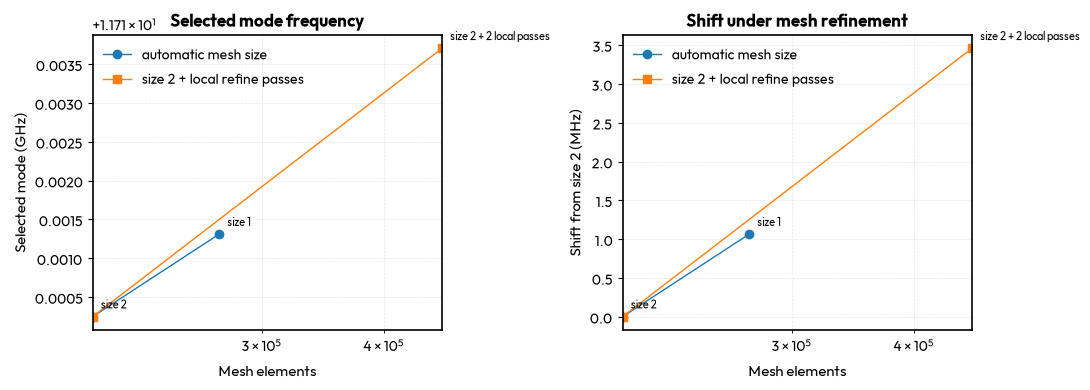

In [11]:
convergence_file = result_file(EIGEN_CONVERGENCE_JSON)

if convergence_file is None:
    explain_missing_results(EIGEN_CONVERGENCE_JSON)
else:
    convergence_payload = json.loads(convergence_file.read_text())
    convergence_rows = convergence_payload.get("rows") or []
    for failure in convergence_payload.get("failures") or []:
        print(f"{failure['label']} failed: {failure['error']}")
    if not convergence_rows:
        explain_missing_results(EIGEN_CONVERGENCE_JSON)
        print("The file on disk carries no rows.")
    else:
        convergence_rows = sorted(convergence_rows, key=itemgetter("element_count"))
        resonance_ghz = np.array(
            [row["resonance_ghz"] for row in convergence_rows], dtype=float
        )
        print(
            f"{'setting':<26} {'elements':>10} {'selected mode (GHz)':>20} "
            f"{'step (MHz)':>10} {'imag (Hz)':>10}"
        )
        for index, row in enumerate(convergence_rows):
            step = ""
            if index > 0:
                step_mhz = (resonance_ghz[index] - resonance_ghz[index - 1]) * 1e3
                step = f"{step_mhz:>+10.3f}"
            print(
                f"{row['label']:<26} {row['element_count']:>10} "
                f"{row['resonance_ghz']:>20.9f} {step:>10} "
                f"{row['imag_frequency_hz']:>+10.3f}"
            )

        if resonance_ghz.size > 1:
            spread_mhz = (resonance_ghz.max() - resonance_ghz.min()) * 1e3
            print(
                f"Spread across the series: {spread_mhz:.3f} MHz, against the "
                f"{2 * SWEEP_HALF_WIDTH_GHZ * 1e6:.0f} kHz width of the sweep "
                "window in the main branch"
            )

        solved_settings = {
            (row["mesh_size"], row["refine_passes"]) for row in convergence_rows
        }
        missing = [
            convergence_label(mesh_size, refine_passes)
            for mesh_size, refine_passes in EIGEN_CONVERGENCE_CONFIGS
            if (mesh_size, refine_passes) not in solved_settings
        ]
        if missing:
            print("No row for: " + ", ".join(missing))

        automatic = [row for row in convergence_rows if row["refine_passes"] == 0]
        localized = sorted(
            (
                row
                for row in convergence_rows
                if row["mesh_size"] == EIGEN_LOCAL_BASE_MESH_SIZE
            ),
            key=itemgetter("refine_passes"),
        )
        reference_ghz = convergence_rows[0]["resonance_ghz"]
        for row in convergence_rows:
            # Derived once so both panels index their series the same way.
            row["shift_mhz"] = (row["resonance_ghz"] - reference_ghz) * 1e3

        fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
        for axis, field, ylabel in (
            (axes[0], "resonance_ghz", "Selected mode (GHz)"),
            (
                axes[1],
                "shift_mhz",
                f"Shift from {convergence_rows[0]['label']} (MHz)",
            ),
        ):
            value_of = itemgetter(field)
            for series, marker, series_label in (
                (automatic, "o", "automatic mesh size"),
                (
                    localized,
                    "s",
                    f"size {EIGEN_LOCAL_BASE_MESH_SIZE} + local refine passes",
                ),
            ):
                axis.plot(
                    [row["element_count"] for row in series],
                    [value_of(row) for row in series],
                    marker=marker,
                    markersize=6,
                    linewidth=1.0,
                    label=series_label,
                )
            for row in convergence_rows:
                axis.annotate(
                    row["label"],
                    (row["element_count"], value_of(row)),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8,
                )
            axis.set_xscale("log")
            axis.set_xlabel("Mesh elements")
            axis.set_ylabel(ylabel)
            axis.grid(True, which="both", alpha=0.3)
            axis.legend()
        axes[0].set_title("Selected mode frequency")
        axes[1].set_title("Shift under mesh refinement")
        plt.tight_layout()
        plt.show()

## Summary

1. Built a coupled quarter-wave resonator, extended both feeds with straight
   CPW to planes clear of the resonator, and extracted a ported layout with
   `crop_to_feed_ports=True`, so both external faces are open CPW cross
   sections. The extension is part of the modelled device and changes the
   coupling geometry relative to the unextended cell.
2. Built the COMSOL sheet model (air, silicon, metal faces on the interface)
   and configured the PEC, the two numeric TEM ports with voltage integration
   lines, and the mesh, all from layout geometry.
3. Solved an eigenfrequency study on a first model, selected the lowest
   high-$Q$ candidate in 8 to 14 GHz, and recorded the full mode spectrum. The
   selection is by frequency and loss ratio alone, so the mode's identity is
   open.
4. Solved a second model over a 200 kHz window at 1 kHz spacing (201
   solutions), centred on that mode, and exported `emw.S21dB`, `emw.S11dB`, and
   the electric field norm at the dip.
5. Replotted the exported sweep and field map: the sweep resolves a dip
   $-15.298$ dB deep at 11.7102458 GHz, the frequency of the selected eigenmode
   to within the spacing of the grid, with the window edges at $-0.0346$ and
   $-0.0110$ dB. No quality factor is read from it.
6. Ran the diagnostic checks that decide how to read that dip, and they do not
   support calling it a resonator resonance: the meander-region field at the
   dip is 0.0666 of the feed-region field, so no meander-localised mode is
   demonstrated; the selected frequency moves 3.46 MHz over the mesh series,
   far more than the 200 kHz window; and the 11.71 GHz high-$Q$ eigenmode
   disappears when the four non-port outer PEC walls become scattering
   boundaries, while port-free PEC and scattering eigenstudies found no
   credible meander-localised mode.

The dip is therefore an apparent feature of the current port and enclosure
setup, possibly an enclosure or termination artifact. Its cause is not proven,
and no QPDK resonator frequency is established by this page. What the page does
establish is a scripted COMSOL workflow, from layout through porting and meshing
to a driven sweep, plus the diagnostic checks that say when a solved feature
should not be trusted. An edge-mesh diagnostic is pending, so these readings may
be revised.

### Limitations

- No validated resonator mode. The selected eigenmode has not been shown to be
  localised on the meander, so the dip is not evidence of a resonance.
- Metal is PEC: no surface resistance and no kinetic inductance, so loss and
  the kinetic-inductance frequency shift are both missing.
- The dip frequency and depth are preliminary: the selected mode moves from
  11.7102458 GHz at 201 391 elements to 11.7137042 GHz at 458 644, and it
  vanishes when the outer PEC walls become scattering boundaries. No quality
  factor is extracted.
- The eigenfrequency search covers 8 to 14 GHz near an 11.6 GHz shift, so a
  mode outside that window would not be found.
- The feed extension is not the reference device, so the solved coupling is
  not the reference coupling.
- The selected mode's imaginary part does not fall as the mesh is refined, and
  it is not monotonic: 1694.030, 147.606, and 930.375 Hz across the three rows.
  It mixes numerical error with the external decay the matched feed ports give
  a lossless PEC model, so no quality factor is read from it.
- The main sweep uses one mesh setting and one enclosure. An adaptive sweep on
  a converged, enclosure-independent physical mode would be needed before the
  dip depth means anything.

### Next steps

- **Establish mode localisation.** Compute the fraction of electric energy in
  the meander region for each eigenmode, and compare the field at the dip
  against a cut at a frequency away from it, so a mode can be identified as the
  resonator mode before its frequency is quoted.
- **Test open walls and the ports.** Replace the four non-port outer PEC walls
  with scattering boundaries in the driven model, and vary the enclosure size
  and the port terminations, to see whether the dip survives.
- **Then converge the physical mode**, and only once one has been identified:
  refine the mesh on that mode and check its frequency and damping settle.
- **Then converge the driven sweep** at those mesh settings on that enclosure
  and confirm the dip frequency and depth stop moving.
- **Then replace PEC** with a surface-impedance or transition boundary
  condition using the superconductor's surface resistance and kinetic
  inductance for a realistic $Q$.
- Compare the ported section against the QPDK analytical and SAX models in
  {doc}`/notebooks/all_models` as a sanity check on the coupling.

## References

```{bibliography}
:filter: docname in docnames
```